In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

print("Libraries Loaded")

ModuleNotFoundError: No module named 'scipy'

In [1]:
from scipy.stats import linregress

print("SciPy Installed Successfully!")

SciPy Installed Successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

print("Libraries Loaded")

Libraries Loaded


In [3]:
nav = pd.read_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\Data\PROCESSED\02_nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)

nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [6]:
nav.to_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\outputs\daily_returns.csv",
    index=False
)

print("Daily Returns Saved!")

Daily Returns Saved!


In [7]:
cagr_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    start_nav = fund.iloc[0]["nav"]
    end_nav = fund.iloc[-1]["nav"]

    years = (
        (fund.iloc[-1]["date"] -
         fund.iloc[0]["date"]).days
        / 365
    )

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
cagr_df.to_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\outputs\cagr_table.csv",
    index=False
)

print("CAGR Saved!")

CAGR Saved!


In [9]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    returns = fund[
        "daily_return"
    ].dropna()

    sharpe = (
        (
            returns.mean() * 252
            - rf
        )
        /
        (
            returns.std()
            * np.sqrt(252)
        )
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [10]:
sortino_results = []

rf = 0.065

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    sortino = (
        (returns.mean() * 252 - rf)
        /
        (downside_std * np.sqrt(252))
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [11]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].copy()

    fund["running_max"] = fund["nav"].cummax()

    fund["drawdown"] = (
        fund["nav"] /
        fund["running_max"]
        - 1
    )

    max_dd = fund["drawdown"].min()

    drawdown_results.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [12]:
benchmark = pd.read_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\Data\PROCESSED\10_benchmark_indices_clean.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [13]:
nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

nifty.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [14]:
alpha_beta_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        ["date", "amfi_code", "daily_return"]
    ]

    fund = fund[
        fund["amfi_code"] == code
    ]

    merged = pd.merge(
        fund,
        nifty[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, alpha, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_annual = alpha * 252

        alpha_beta_results.append(
            [
                code,
                alpha_annual,
                beta
            ]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [15]:
alpha_beta_df.to_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\outputs\alpha_beta.csv",
    index=False
)

print("Alpha Beta Saved!")

Alpha Beta Saved!


In [16]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [17]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown
0,100016,0.026352,-0.201517,0.037476,-0.058268,-0.247344
1,100025,0.044551,-0.567095,0.042818,0.001158,-0.043083
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172
3,101206,0.235205,1.027213,0.213998,0.021086,-0.112916
4,101207,0.079331,0.162661,0.108971,-0.065289,-0.354469


In [18]:
performance = pd.read_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\Data\PROCESSED\07_scheme_performance_clean.csv"
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,0.026352,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,0.044551,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,0.235205,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,0.079331,0.162661,0.108971,-0.065289,-0.354469,1.53


In [19]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["dd_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

scorecard["fund_score"] = (
      scorecard["cagr_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["dd_rank"] * 0.10
)

In [20]:
scorecard["fund_score"] = (
    100 *
    (
        scorecard["fund_score"].max()
        - scorecard["fund_score"]
    )
    /
    (
        scorecard["fund_score"].max()
        - scorecard["fund_score"].min()
    )
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
0,100016,0.026352,-0.201517,0.037476,-0.058268,-0.247344,1.55,37.0,35.0,39.0,32.0,34.0,1.110162
1,100025,0.044551,-0.567095,0.042818,0.001158,-0.043083,0.56,36.0,39.0,38.0,2.0,4.0,25.021349
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,90.777114
3,101206,0.235205,1.027213,0.213998,0.021086,-0.112916,1.60,12.0,9.0,12.0,36.5,9.0,73.612297
4,101207,0.079331,0.162661,0.108971,-0.065289,-0.354469,1.53,27.0,28.0,27.0,28.5,38.0,25.960717


In [21]:
top10 = scorecard.sort_values(
    "fund_score",
    ascending=False
)

top10[
    ["amfi_code", "fund_score"]
].head(10)

,amfi_code,fund_score
25,120505,100.000000
34,148567,98.292058
30,120843,96.584116
2,100033,90.777114
36,148569,88.300598
21,119598,85.824082
24,120504,82.578992
20,119552,81.895816
39,149324,81.810418
19,119551,81.639624


In [22]:
scorecard.to_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\outputs\fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved!")

Fund Scorecard Saved!


In [23]:
top5_codes = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5_codes

[120505, 148567, 120843, 100033, 148569]

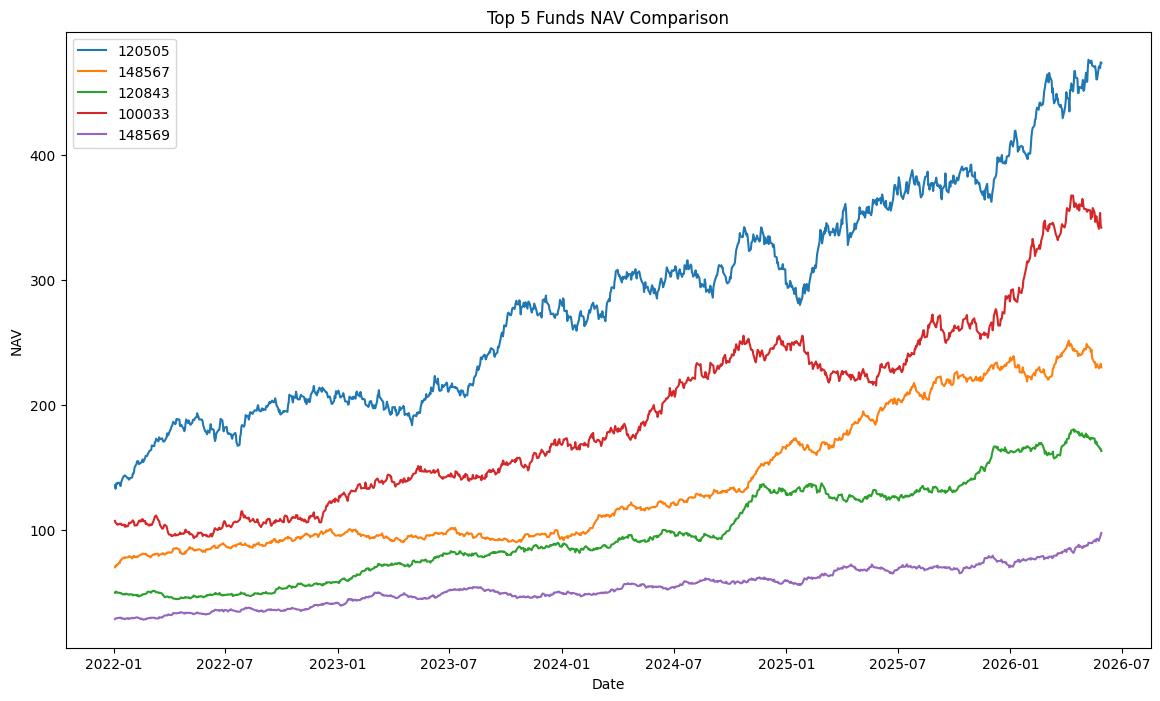

Benchmark Comparison Chart Saved!


In [24]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.savefig(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\outputs\benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

print("Benchmark Comparison Chart Saved!")

In [25]:
tracking_error_results = []

for code in top5_codes:

    fund = nav[
        ["date", "amfi_code", "daily_return"]
    ]

    fund = fund[
        fund["amfi_code"] == code
    ]

    merged = pd.merge(
        fund,
        nifty[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["daily_return"]
         - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [code, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.231968
1,148567,0.189664
2,120843,0.206425
3,100033,0.228699
4,148569,0.217365


In [26]:
tracking_error_df.to_csv(
    r"C:\Users\UDAY KIRAN\Desktop\mutual fund analytics\outputs\tracking_error.csv",
    index=False
)

print("Tracking Error Saved!")

Tracking Error Saved!
